<a href="https://colab.research.google.com/github/Jee8825/jeeva-codebooster-2026/blob/main/Day_5/Day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [42]:
df=pd.read_csv('student_performance.csv')
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [43]:
print(df.shape[0],
df.shape[1],
df.isnull().sum().sum())

30 13 0


In [44]:
print(df.describe())

        student_id        age  ...  attendance_percentage  admission_year
count    30.000000  30.000000  ...              30.000000            30.0
mean   1015.500000  19.733333  ...              84.500000          2023.0
std       8.803408   0.739680  ...               9.379913             0.0
min    1001.000000  19.000000  ...              65.000000          2023.0
25%    1008.250000  19.000000  ...              77.250000          2023.0
50%    1015.500000  20.000000  ...              86.500000          2023.0
75%    1022.750000  20.000000  ...              91.750000          2023.0
max    1030.000000  21.000000  ...              98.000000          2023.0

[8 rows x 9 columns]


In [45]:
df_ml=df.copy()

In [46]:
df_ml = df.copy()

le_gender = LabelEncoder()

df_ml['gender_encoded'] = le_gender.fit_transform(df_ml['gender'])

print(f'Gender encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}')

le_dept = LabelEncoder()

df_ml['department_encoded'] = le_dept.fit_transform(df_ml['department'])

print(f'Department encoding: {dict(zip(le_dept.classes_, le_dept.transform(le_dept.classes_)))}')

print('\nNew columns added: gender_encoded, department_encoded')

df_ml[['gender', 'gender_encoded',

       'department', 'department_encoded']].head(5)

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}
Department encoding: {'Civil': np.int64(0), 'Computer Science': np.int64(1), 'Electronics': np.int64(2), 'Mechanical': np.int64(3)}

New columns added: gender_encoded, department_encoded


,gender,gender_encoded,department,department_encoded
0,Male,1,Computer Science,1
1,Female,0,Computer Science,1
2,Male,1,Electronics,2
3,Female,0,Mechanical,3
4,Male,1,Computer Science,1


In [47]:
feature_cols=['math_score','science_score','english_score','attendance_percentage','gender_encoded','department_encoded']
X=df_ml[feature_cols]
y=df_ml['programming_score']
print('Feature matrix',X.shape,',target_vector',y.shape)
print('Feature Cols',feature_cols)
print('Targeted col:programming_score')
print(y.min(),y.max(),y.mean())

Feature matrix (30, 6) ,target_vector (30,)
Feature Cols ['math_score', 'science_score', 'english_score', 'attendance_percentage', 'gender_encoded', 'department_encoded']
Targeted col:programming_score
38 97 67.6


In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total students: {len(df_ml)}")
print(f"Training students: {len(X_train)}", len(X_train)/len(X)*100,'%')
print(f"Testing students: {len(X_test)}", len(X_test)/len(X)*100,'%')

print(f"\nTraining target (programming_score) range: {y_train.min()} to {y_train.max()}")
print(f"Testing target (programming_score) range: {y_test.min()} to {y_test.max()}")

Total students: 30
Training students: 24 80.0 %
Testing students: 6 20.0 %

Training target (programming_score) range: 38 to 96
Testing target (programming_score) range: 39 to 97


In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

print(f"Overall mean of scaled training data: {np.mean(X_train_scaled):.2f}")
print(f"Overall standard deviation of scaled training data: {np.std(X_train_scaled):.2f}")



Scaling complete.
Overall mean of scaled training data: -0.00
Overall standard deviation of scaled training data: 1.00


In [50]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("=== Model 1: Linear Regression ===")

print(f"MAE : {lr_mae:.2f} "
      f"(predictions are off by {lr_mae:.1f} points on average)")

print(f"RMSE : {lr_rmse:.2f} "
      f"(error with penalty for large mistakes)")

print(f"R² : {lr_r2:.4f} "
      f"({lr_r2*100:.1f}% of programming score variation explained)")

print()

print("Learned coefficients (importance of each feature):")

for feat, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {feat:<28}: {coef:+.3f}")

print(f"  {'bias (intercept)':<28}: "
      f"{lr_model.intercept_:+.3f}")

=== Model 1: Linear Regression ===
MAE : 9.37 (predictions are off by 9.4 points on average)
RMSE : 11.47 (error with penalty for large mistakes)
R² : 0.7356 (73.6% of programming score variation explained)

Learned coefficients (importance of each feature):
  math_score                  : +20.256
  science_score               : +7.612
  english_score               : +2.396
  attendance_percentage       : -12.886
  gender_encoded              : -0.397
  department_encoded          : -0.449
  bias (intercept)            : +68.042


In [51]:
print(lr_pred)

[ 43.52279428  85.70354782  72.06136603  93.84511298  55.49110947
 100.60008833]


In [52]:
dt_model =DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)


print("mae:",dt_mae)
print("rmse:",dt_rmse)
print("R²:",dt_r2)

mae: 9.833333333333334
rmse: 14.756354563373707
R²: 0.5622871182087219


In [53]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("=== Model 3: Random Forest ===")
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

=== Model 3: Random Forest ===
MAE : 9.68
RMSE: 12.43
R²  : 0.6894


In [54]:
comparison_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [lr_mae, dt_mae, rf_mae],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse],
    'R2 Score': [lr_r2, dt_r2, rf_r2]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.sort_values(by='R2 Score', ascending=False))

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.370670,11.469004,0.735587
2,Random Forest,9.678333,12.430497,0.689395
1,Decision Tree,9.833333,14.756355,0.562287


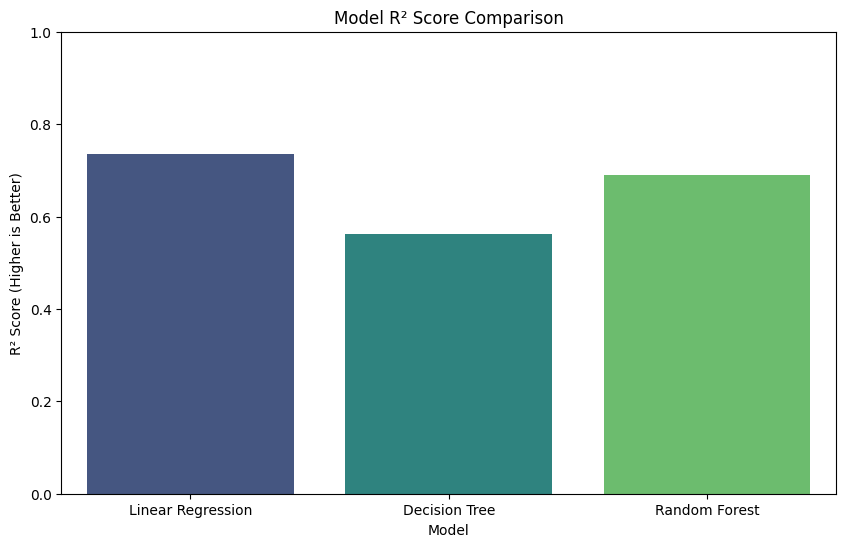

In [55]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=comparison_df, palette='viridis')
plt.title('Model R² Score Comparison')
plt.ylim(0, 1)
plt.ylabel('R² Score (Higher is Better)')
plt.show()

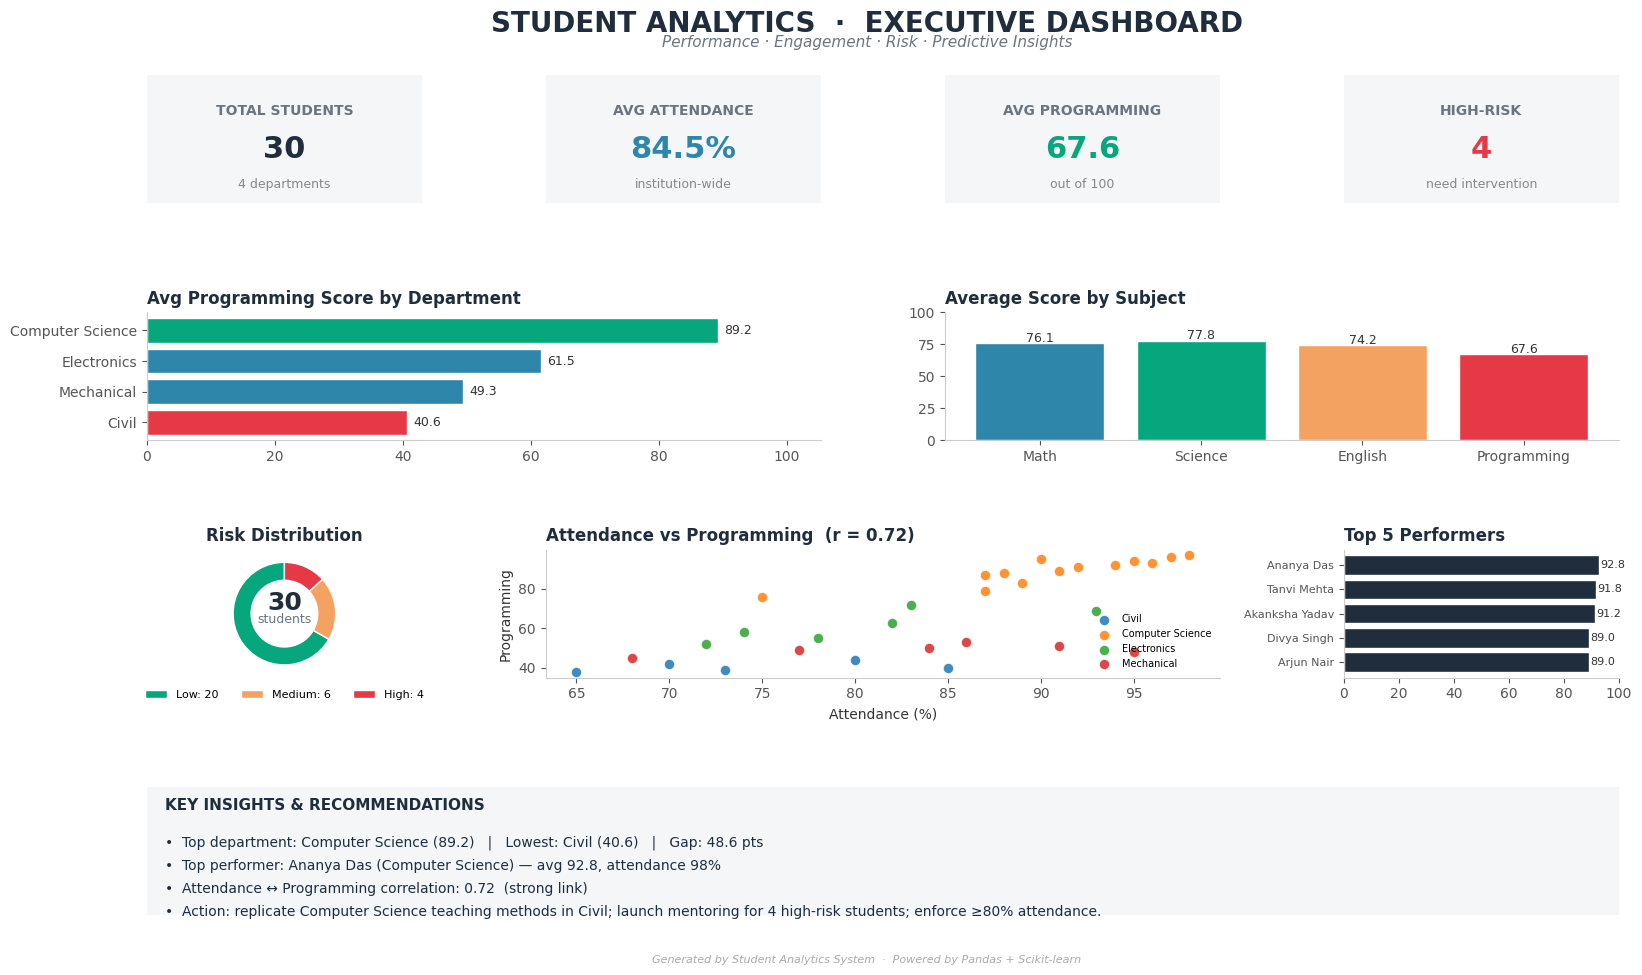

Dashboard saved → student_dashboard.png


In [56]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ---------- prep metrics ----------
total_students   = len(df)
avg_attendance   = df['attendance_percentage'].mean()
avg_programming  = df['programming_score'].mean()
dept_count       = df['department'].nunique()

dept_summary_sorted = (
    df.groupby('department')['programming_score']
      .mean().round(2).sort_values(ascending=True)
)
best_dept_prog   = dept_summary_sorted.index[-1]
best_dept_score  = dept_summary_sorted.iloc[-1]
worst_dept_prog  = dept_summary_sorted.index[0]
worst_dept_score = dept_summary_sorted.iloc[0]

high_risk_count = ((df['attendance_percentage'] < 75) & (df['programming_score'] < 50)).sum()
med_risk_count  = (((df['attendance_percentage'] < 75) | (df['programming_score'] < 50))
                   & ~((df['attendance_percentage'] < 75) & (df['programming_score'] < 50))).sum()
low_risk_count  = total_students - high_risk_count - med_risk_count

att_corr = df['attendance_percentage'].corr(df['programming_score'])

top_student = (
    df.assign(overall=(df['math_score']+df['science_score']+df['english_score']+df['programming_score'])/4)
      .sort_values('overall', ascending=False).iloc[0]
)

subject_cols = ['math_score','science_score','english_score','programming_score']
subject_means = df[subject_cols].mean()

# ---------- style ----------
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#cccccc',
    'axes.labelcolor': '#333333',
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.titlecolor': '#1f2d3d',
})

NAVY   = '#1f2d3d'
BLUE   = '#2E86AB'
TEAL   = '#06A77D'
AMBER  = '#F4A261'
RED    = '#E63946'
LIGHT  = '#F4F6F8'

fig = plt.figure(figsize=(16, 10), facecolor='white')
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.85, wspace=0.45,
                        left=0.05, right=0.97, top=0.90, bottom=0.06)

# ---------- header ----------
fig.suptitle('STUDENT ANALYTICS  ·  EXECUTIVE DASHBOARD',
             fontsize=20, fontweight='bold', color=NAVY, y=0.965)
fig.text(0.5, 0.928, 'Performance · Engagement · Risk · Predictive Insights',
         ha='center', fontsize=11, color='#6c757d', style='italic')

# ---------- KPI cards ----------
def kpi(ax, title, value, sub, color):
    ax.set_facecolor(LIGHT)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, title, ha='center', va='center',
            fontsize=10, color='#6c757d', weight='bold')
    ax.text(0.5, 0.42, value, ha='center', va='center',
            fontsize=22, color=color, weight='bold')
    ax.text(0.5, 0.15, sub, ha='center', va='center',
            fontsize=9, color='#888888')

kpi(fig.add_subplot(gs[0,0]), 'TOTAL STUDENTS',  f'{total_students}',
    f'{dept_count} departments', NAVY)
kpi(fig.add_subplot(gs[0,1]), 'AVG ATTENDANCE',  f'{avg_attendance:.1f}%',
    'institution-wide', BLUE)
kpi(fig.add_subplot(gs[0,2]), 'AVG PROGRAMMING', f'{avg_programming:.1f}',
    'out of 100', TEAL)
kpi(fig.add_subplot(gs[0,3]), 'HIGH-RISK',       f'{high_risk_count}',
    'need intervention', RED)

# ---------- department bar ----------
ax1 = fig.add_subplot(gs[1, 0:2])
colors = [TEAL if d == best_dept_prog else RED if d == worst_dept_prog else BLUE
          for d in dept_summary_sorted.index]
bars = ax1.barh(dept_summary_sorted.index, dept_summary_sorted.values,
                color=colors, edgecolor='white')
for b, v in zip(bars, dept_summary_sorted.values):
    ax1.text(v + 1, b.get_y() + b.get_height()/2, f'{v:.1f}',
             va='center', fontsize=9, color='#333')
ax1.set_title('Avg Programming Score by Department', loc='left')
ax1.set_xlim(0, max(dept_summary_sorted.values) * 1.18)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# ---------- subject means radar-ish bar ----------
ax2 = fig.add_subplot(gs[1, 2:4])
sb = ax2.bar(['Math','Science','English','Programming'], subject_means.values,
             color=[BLUE, TEAL, AMBER, RED], edgecolor='white')
for b, v in zip(sb, subject_means.values):
    ax2.text(b.get_x() + b.get_width()/2, v + 1, f'{v:.1f}',
             ha='center', fontsize=9, color='#333')
ax2.set_title('Average Score by Subject', loc='left')
ax2.set_ylim(0, 100)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# ---------- risk donut ----------
ax3 = fig.add_subplot(gs[2, 0])
sizes  = [low_risk_count, med_risk_count, high_risk_count]
labels = ['Low', 'Medium', 'High']
colors_r = [TEAL, AMBER, RED]
wedges, _ = ax3.pie(sizes, colors=colors_r, startangle=90,
                    wedgeprops=dict(width=0.35, edgecolor='white'))
ax3.text(0, 0.08, f'{total_students}', ha='center', fontsize=18,
         weight='bold', color=NAVY)
ax3.text(0, -0.18, 'students', ha='center', fontsize=9, color='#6c757d')
ax3.set_title('Risk Distribution', loc='center')
ax3.legend(wedges, [f'{l}: {s}' for l, s in zip(labels, sizes)],
           loc='lower center', bbox_to_anchor=(0.5, -0.25),
           frameon=False, fontsize=8, ncol=3)

# ---------- attendance vs programming scatter ----------
ax4 = fig.add_subplot(gs[2, 1:3])
for dept, sub in df.groupby('department'):
    ax4.scatter(sub['attendance_percentage'], sub['programming_score'],
                label=dept, s=60, alpha=0.85, edgecolor='white')
ax4.set_title(f'Attendance vs Programming  (r = {att_corr:.2f})', loc='left')
ax4.set_xlabel('Attendance (%)'); ax4.set_ylabel('Programming')
ax4.legend(fontsize=7, loc='lower right', frameon=False)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

# ---------- top performers ----------
ax5 = fig.add_subplot(gs[2, 3])
top5 = (df.assign(overall=(df['math_score']+df['science_score']
        +df['english_score']+df['programming_score'])/4)
          .sort_values('overall', ascending=True).tail(5))
ax5.barh(top5['name'], top5['overall'], color=NAVY, edgecolor='white')
for i, v in enumerate(top5['overall'].values):
    ax5.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=8, color='#333')
ax5.set_title('Top 5 Performers', loc='left')
ax5.set_xlim(0, 100)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)
ax5.tick_params(axis='y', labelsize=8)

# ---------- insights panel ----------
ax6 = fig.add_subplot(gs[3, :])
ax6.set_facecolor(LIGHT)
for s in ax6.spines.values(): s.set_visible(False)
ax6.set_xticks([]); ax6.set_yticks([])
ax6.text(0.012, 0.82, 'KEY INSIGHTS & RECOMMENDATIONS',
         fontsize=11, weight='bold', color=NAVY)

insights = [
    f"Top department: {best_dept_prog} ({best_dept_score:.1f})   |   "
    f"Lowest: {worst_dept_prog} ({worst_dept_score:.1f})   |   "
    f"Gap: {best_dept_score - worst_dept_score:.1f} pts",
    f"Top performer: {top_student['name']} ({top_student['department']}) — "
    f"avg {top_student['overall']:.1f}, attendance {top_student['attendance_percentage']}%",
    f"Attendance ↔ Programming correlation: {att_corr:.2f}  "
    f"({'strong' if abs(att_corr)>0.6 else 'moderate' if abs(att_corr)>0.3 else 'weak'} link)",
    f"Action: replicate {best_dept_prog} teaching methods in {worst_dept_prog}; "
    f"launch mentoring for {high_risk_count} high-risk students; enforce ≥80% attendance.",
]
for i, line in enumerate(insights):
    ax6.text(0.012, 0.62 - i*0.18, f'•  {line}',
             fontsize=10, color='#1f2d3d', va='top')

# ---------- footer ----------
fig.text(0.5, 0.012, 'Generated by Student Analytics System  ·  Powered by Pandas + Scikit-learn',
         ha='center', fontsize=8, color='#aaaaaa', style='italic')

plt.savefig('student_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Dashboard saved → student_dashboard.png')